# Sprint 47 — Profondeur & schéma de quantification (EWC)

Second axe de la quantification, **orthogonal** au *moment* (Sprint 46) : *jusqu'où descendre en bits* (sub-INT8) avant que la tête EWC casse, et *quelle calibration* (granularité / symétrie) rachète la métrique. **PC/émulateur bit-exact** — le portage board est le Sprint 48.

Toutes les valeurs de ce notebook sont **rechargées depuis les JSON** (`experiments/exp_S47_*`) via `src/figures/loaders.py` — aucun chiffre en dur. Les figures sont régénérées par le catalogue `quant_depth` (`src/figures/`).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib
matplotlib.use('Agg')
from src.figures import registry
import src.figures.catalogs  # noqa: F401 — auto-enregistrement
from src.figures.loaders import load_experiment, metric_or_na
from src.figures.style import apply_style
from src.utils.reproducibility import set_seed

apply_style('slide')
set_seed(42)
print('catalogues :', [c for c in registry.list_catalogs() if 'quant_depth' in c])

✅ Seed fixé à 42
catalogues : ['quant_depth']


## 1. Régénération des figures

Le catalogue `quant_depth` produit 5 PNG sous `docs/figures/quantization_depth/`.

In [2]:
paths = registry.get_catalog('quant_depth')(ROOT / 'docs' / 'figures')
for p in paths:
    print(p.relative_to(ROOT))

[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization_depth/auroc_vs_bits.png
[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization_depth/heatmap_bits_granularity.png


[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization_depth/ram_vs_bits.png
[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization_depth/symmetry_gain.png


[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization_depth/scope_context.png
docs/figures/quantization_depth/auroc_vs_bits.png
docs/figures/quantization_depth/heatmap_bits_granularity.png
docs/figures/quantization_depth/ram_vs_bits.png
docs/figures/quantization_depth/symmetry_gain.png
docs/figures/quantization_depth/scope_context.png


## 2. Galerie

### Δ AUROC vs profondeur (par granularité, par dataset)

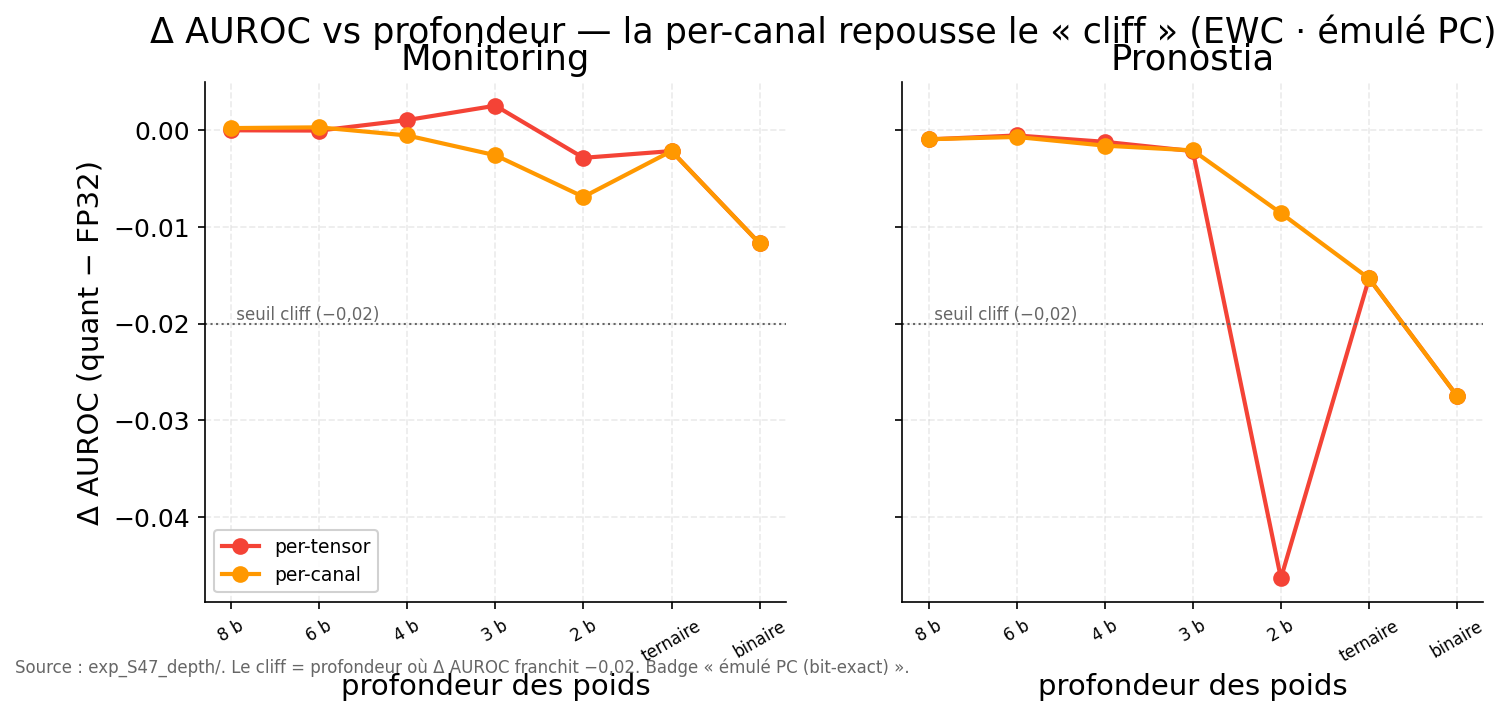

In [3]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / 'docs' / 'figures' / 'quantization_depth' / 'auroc_vs_bits.png')))

### Heatmap Δ AUROC (bits × granularité)

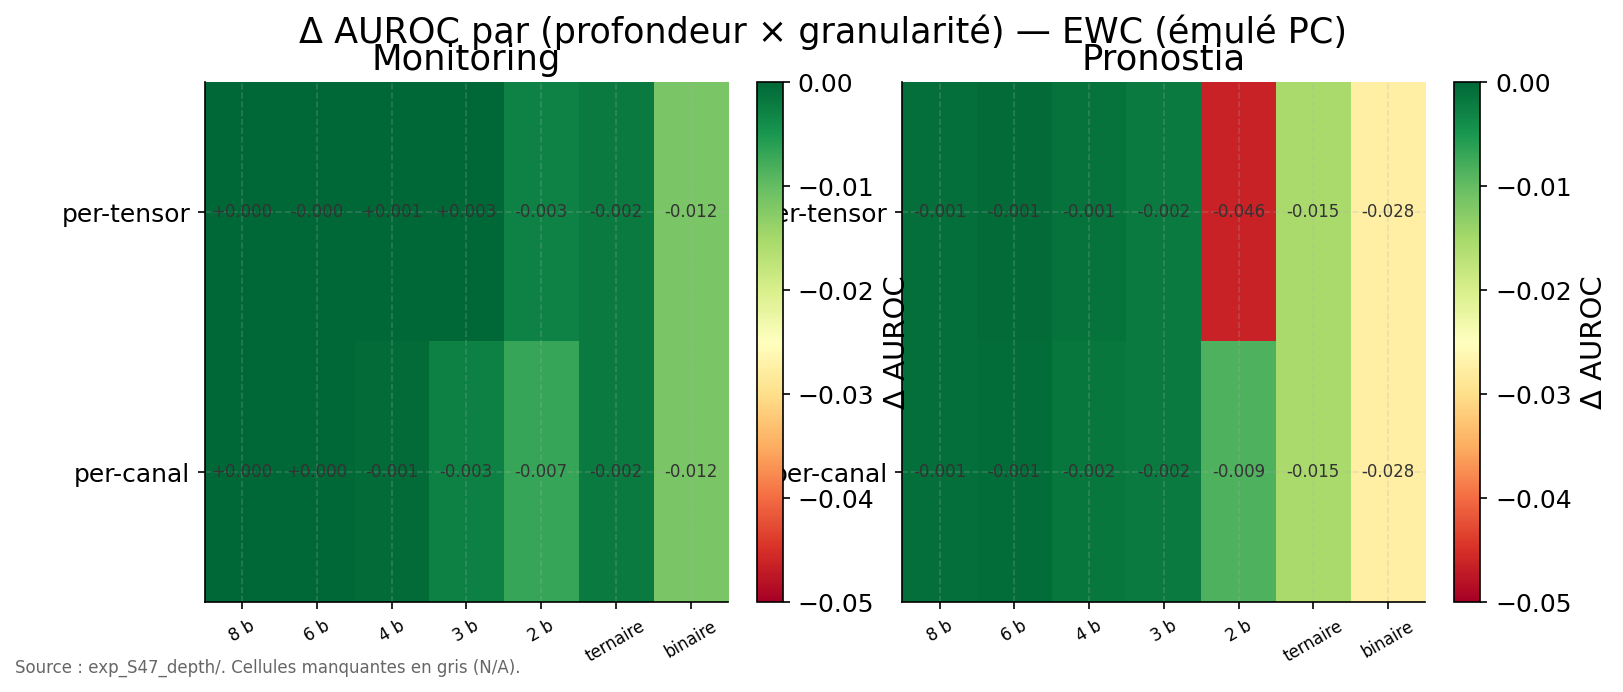

In [4]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / 'docs' / 'figures' / 'quantization_depth' / 'heatmap_bits_granularity.png')))

### Gain RAM théorique (bit-packée) vs profondeur

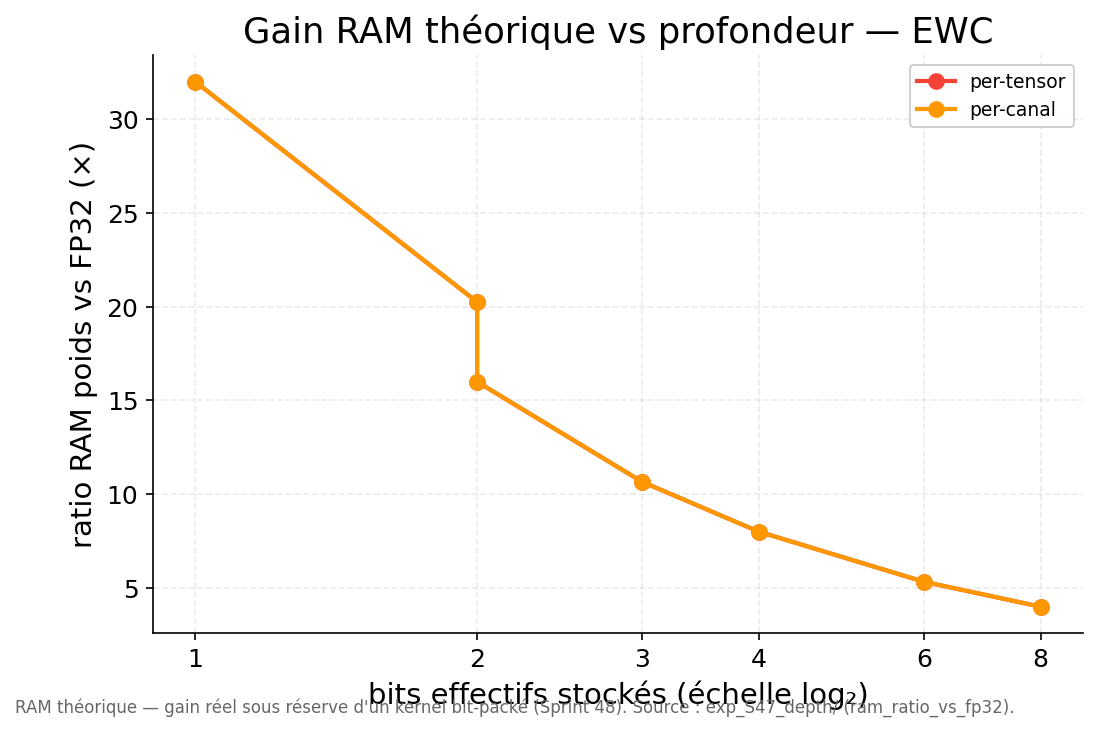

In [5]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / 'docs' / 'figures' / 'quantization_depth' / 'ram_vs_bits.png')))

### Zero-point affine vs symétrique aux bits critiques

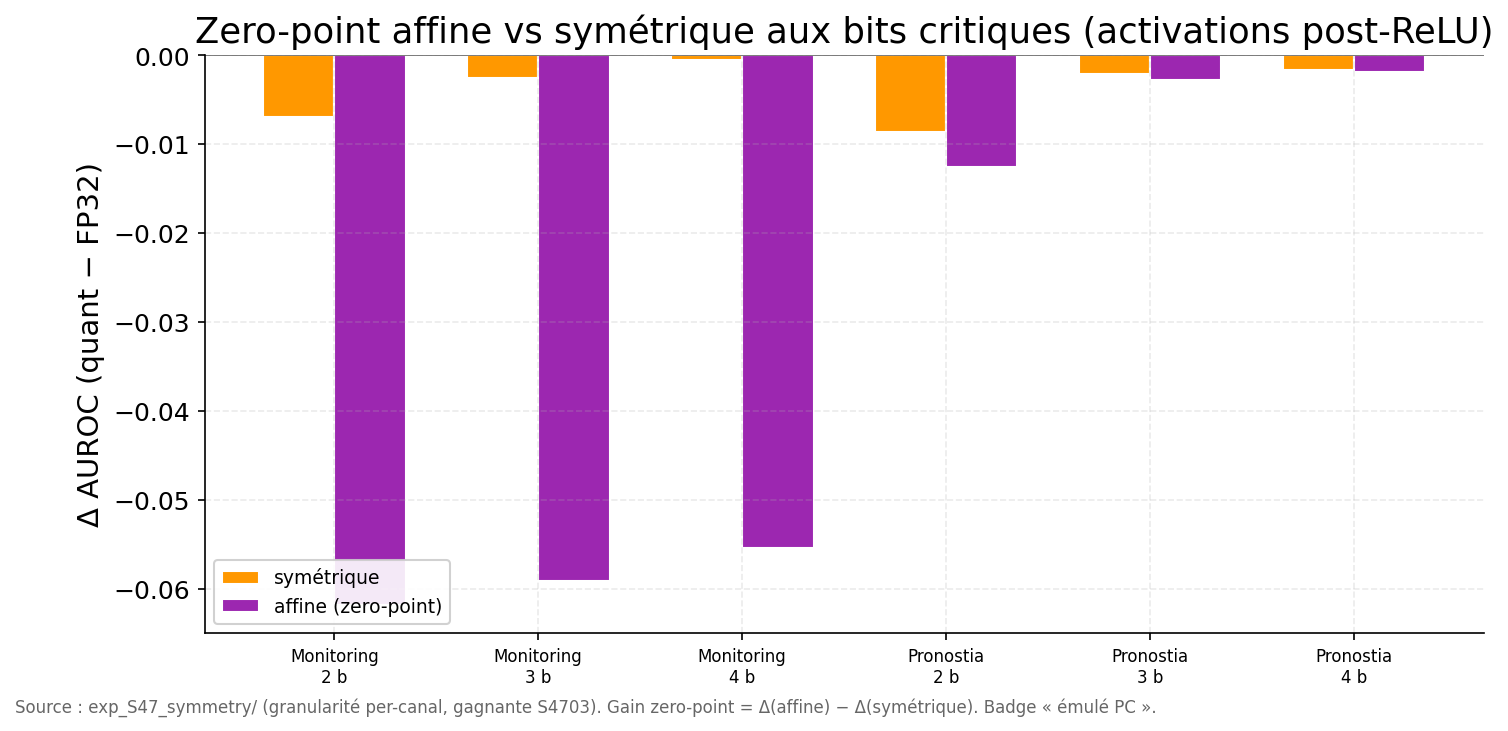

In [6]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / 'docs' / 'figures' / 'quantization_depth' / 'symmetry_gain.png')))

### Périmètre EWC-only ∥ HDC/Maha/TinyOL N/A

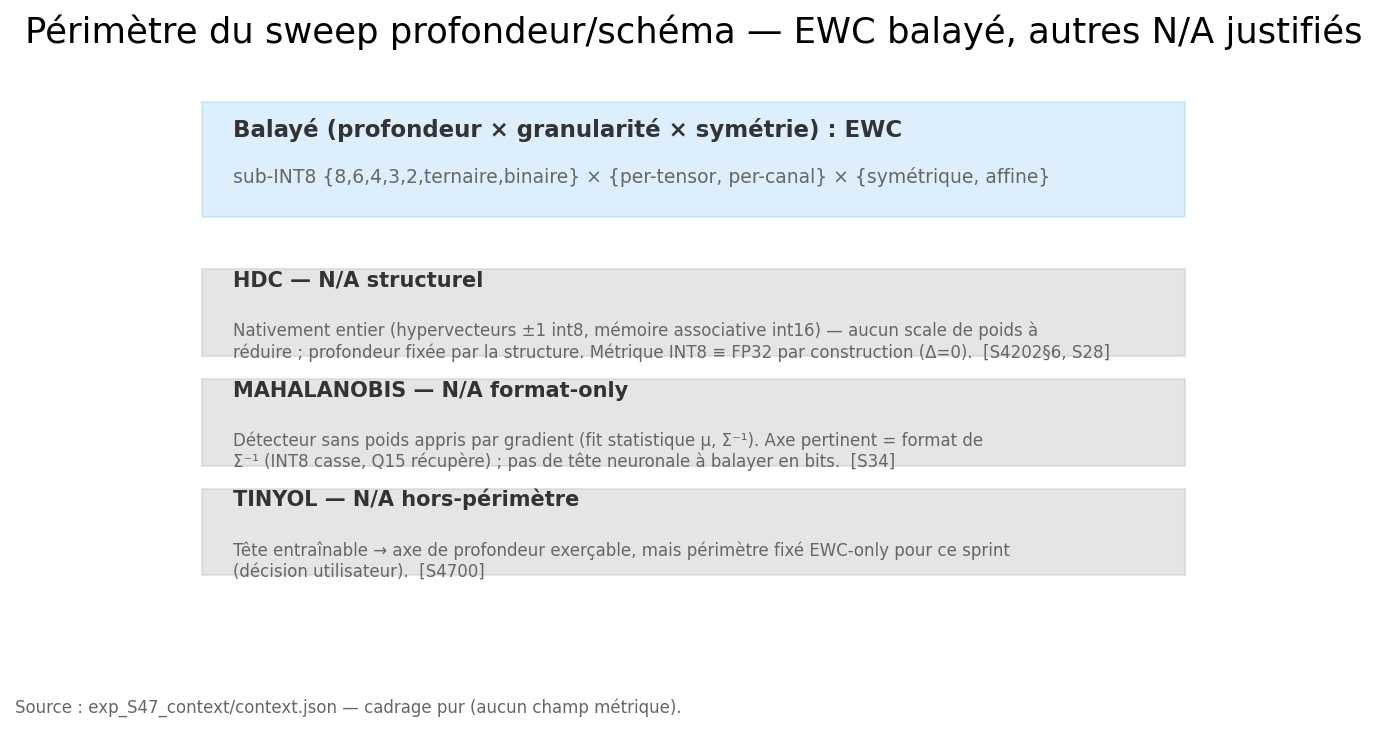

In [7]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / 'docs' / 'figures' / 'quantization_depth' / 'scope_context.png')))

## 3. Tableau de synthèse (Δ AUROC, rechargé depuis les JSON)

`delta_auroc` par (dataset × granularité × profondeur) — aucune valeur en dur.

In [8]:
DATASETS = ['monitoring', 'pronostia']
GRANS = ['per_tensor', 'per_channel']
TAGS = ['int8', 'int6', 'int4', 'int3', 'int2', 'ternaire', 'binaire']

def depth_delta(ds, tag, gran):
    try:
        data, _ = load_experiment(f'experiments/exp_S47_depth/exp_S47_ewc_{ds}_{tag}_{gran}.json')
    except FileNotFoundError:
        return None
    v = metric_or_na(data, 'delta_auroc')
    return v if isinstance(v, (int, float)) else None

hdr = f"{'dataset':<11}{'granularité':<13}" + ''.join(f'{t:>10}' for t in TAGS)
print(hdr)
print('-' * len(hdr))
for ds in DATASETS:
    for gran in GRANS:
        row = f'{ds:<11}{gran:<13}'
        for t in TAGS:
            v = depth_delta(ds, t, gran)
            row += f'{v:>+10.4f}' if v is not None else f"{'N/A':>10}"
        print(row)

dataset    granularité        int8      int6      int4      int3      int2  ternaire   binaire
----------------------------------------------------------------------------------------------
monitoring per_tensor      +0.0000   -0.0000   +0.0011   +0.0026   -0.0028   -0.0021   -0.0117
monitoring per_channel     +0.0002   +0.0003   -0.0005   -0.0026   -0.0069   -0.0021   -0.0117
pronostia  per_tensor      -0.0009   -0.0005   -0.0012   -0.0021   -0.0464   -0.0153   -0.0275
pronostia  per_channel     -0.0009   -0.0007   -0.0016   -0.0021   -0.0086   -0.0153   -0.0275


## 4. Recommandation — plus petit `weight_bits` viable (Δ AUROC ≥ −0,02)

Le seuil de dégradation −0,02 et le gain RAM sont **calculés depuis les JSON**.

In [9]:
SEUIL = -0.02  # seuil de dégradation (cadrage, pas un résultat mesuré)

def ram_ratio(ds, tag, gran):
    try:
        data, _ = load_experiment(f'experiments/exp_S47_depth/exp_S47_ewc_{ds}_{tag}_{gran}.json')
    except FileNotFoundError:
        return None
    v = metric_or_na(data, 'ram_ratio_vs_fp32')
    return v if isinstance(v, (int, float)) else None

for ds in DATASETS:
    for gran in GRANS:
        viable = [t for t in TAGS
                  if (d := depth_delta(ds, t, gran)) is not None and d >= SEUIL]
        if viable:
            best = viable[-1]  # TAGS ordonné du plus profond au plus bas
            print(f'{ds:<11}{gran:<13} → {best:<9} '
                  f'(Δ={depth_delta(ds, best, gran):+.4f}, RAM ×{ram_ratio(ds, best, gran)})')
        else:
            print(f'{ds:<11}{gran:<13} → aucun sous le seuil')

monitoring per_tensor    → binaire   (Δ=-0.0117, RAM ×32.0)
monitoring per_channel   → binaire   (Δ=-0.0117, RAM ×32.0)
pronostia  per_tensor    → ternaire  (Δ=-0.0153, RAM ×20.2532)
pronostia  per_channel   → ternaire  (Δ=-0.0153, RAM ×20.2532)


## 5. Axe symétrie — gain du zero-point affine (bits critiques)

`Δ(affine) − Δ(symétrique)` par (dataset, profondeur), rechargé depuis `exp_S47_symmetry/`. Un gain positif = le zero-point rachète de l'AUROC.

In [10]:
CRIT = ['int2', 'int3', 'int4']

def sym_delta(ds, tag, sym):
    try:
        data, _ = load_experiment(f'experiments/exp_S47_symmetry/exp_S47_ewc_{ds}_{tag}_{sym}.json')
    except FileNotFoundError:
        return None
    v = metric_or_na(data, 'delta_auroc')
    return v if isinstance(v, (int, float)) else None

print(f"{'dataset':<11}{'bits':<8}{'symétrique':>12}{'affine':>10}{'gain affine':>14}")
print('-' * 55)
for ds in DATASETS:
    for t in CRIT:
        s = sym_delta(ds, t, 'symmetric')
        a = sym_delta(ds, t, 'affine')
        gain = (a - s) if (s is not None and a is not None) else None
        srepr = f'{s:+.4f}' if s is not None else 'N/A'
        arepr = f'{a:+.4f}' if a is not None else 'N/A'
        grepr = f'{gain:+.4f}' if gain is not None else 'N/A'
        print(f'{ds:<11}{t:<8}{srepr:>12}{arepr:>10}{grepr:>14}')

dataset    bits      symétrique    affine   gain affine
-------------------------------------------------------
monitoring int2         -0.0069   -0.0619       -0.0550
monitoring int3         -0.0026   -0.0591       -0.0565
monitoring int4         -0.0005   -0.0554       -0.0549
pronostia  int2         -0.0086   -0.0125       -0.0040
pronostia  int3         -0.0021   -0.0028       -0.0007
pronostia  int4         -0.0016   -0.0019       -0.0003


## 6. Contexte N/A (HDC / Mahalanobis / TinyOL)

Cadrage pur — aucun résultat fabriqué (cf. S4705).

In [11]:
ctx, _ = load_experiment('experiments/exp_S47_context/context.json')
print('modèles balayés :', ctx['swept_models'])
for name, info in ctx['context_models'].items():
    print(f"\n{name.upper()} [{info['status']}] (réf. {info['ref']})")
    print(' ', info['reason'])

modèles balayés : ['ewc']

HDC [na_structural] (réf. S4202§6, S28)
  Nativement entier (hypervecteurs ±1 int8, mémoire associative int16) — aucun scale de poids à réduire ; profondeur fixée par la structure. Métrique INT8 ≡ FP32 par construction (Δ=0).

MAHALANOBIS [na_format_only] (réf. S34)
  Détecteur sans poids appris par gradient (fit statistique μ, Σ⁻¹). Axe pertinent = format de Σ⁻¹ (INT8 casse, Q15 récupère) ; pas de tête neuronale à balayer en bits.

TINYOL [na_out_of_scope] (réf. S4700)
  Tête entraînable → axe de profondeur exerçable, mais périmètre fixé EWC-only pour ce sprint (décision utilisateur).


---
**Lecture d'ensemble.** La per-canal repousse le « cliff » en profondeur (Pronostia), le zero-point affine n'apporte pas de gain décisif ici (per-canal suffit), et le gain RAM sub-INT8 reste **théorique** tant qu'un kernel bit-packé n'est pas porté (Sprint 48).